In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

In [ ]:
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

In [ ]:
x_train_cnn = x_train
x_test_cnn = x_test


Model 1 : neural network


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
nn_model = Sequential([
    Dense(512, activation='relu', input_shape=(32*32*3,)),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

In [ ]:
nn_model.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])


In [10]:
nn_model.fit(x_train_flat, y_train, epochs=20, batch_size=64, validation_split=0.2)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 0.2577 - loss: 2.1252 - val_accuracy: 0.3585 - val_loss: 1.7690
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.3826 - loss: 1.7157 - val_accuracy: 0.4166 - val_loss: 1.6358
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.4170 - loss: 1.6150 - val_accuracy: 0.4364 - val_loss: 1.6048
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.4464 - loss: 1.5506 - val_accuracy: 0.4162 - val_loss: 1.6387
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.4647 - loss: 1.4983 - val_accuracy: 0.4479 - val_loss: 1.5603
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.4645 - loss: 1.4889 - val_accuracy: 0.4536 - val_loss: 1.5379
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.4884 - loss: 1.4355 - val_accuracy: 0.4622 - val_loss: 1.5257
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - accuracy: 0.4955 - loss: 1.4105 - 

In [11]:
nn_loss, nn_acc = nn_model.evaluate(x_test_flat, y_test)
print(nn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4936 - loss: 1.4951
0.486299991607666


Model 2: CNN

In [12]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [13]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

In [15]:
cnn_model.fit(x_train_cnn, y_train, epochs=20, batch_size=64, validation_split=0.2)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 160ms/step - accuracy: 0.3422 - loss: 1.7735 - val_accuracy: 0.5450 - val_loss: 1.2740
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 138s 155ms/step - accuracy: 0.5971 - loss: 1.1457 - val_accuracy: 0.6565 - val_loss: 0.9971
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 146s 161ms/step - accuracy: 0.6709 - loss: 0.9390 - val_accuracy: 0.6565 - val_loss: 0.9769
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 157ms/step - accuracy: 0.7153 - loss: 0.8076 - val_accuracy: 0.7115 - val_loss: 0.8470
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 99s 159ms/step - accuracy: 0.7558 - loss: 0.7027 - val_accuracy: 0.7243 - val_loss: 0.8092
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 159ms/step - accuracy: 0.7844 - loss: 0.6269 - val_accuracy: 0.7313 - val_loss: 0.8003
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 139s 154ms/step - accuracy: 0.8107 - loss: 0.5440 - val_accuracy: 0.7234 - val_loss: 0.8349
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 155ms/step - accuracy: 0.8360 - lo

In [16]:
cnn_loss, cnn_acc = cnn_model.evaluate(x_test_cnn, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7138 - loss: 1.6045


In [17]:
print(cnn_acc)

0.7124000191688538


In [18]:
import matplotlib.pyplot as plt
import numpy as np

Evaluation and results


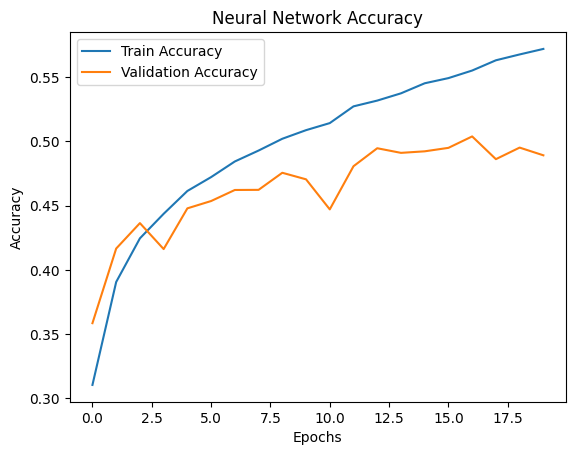

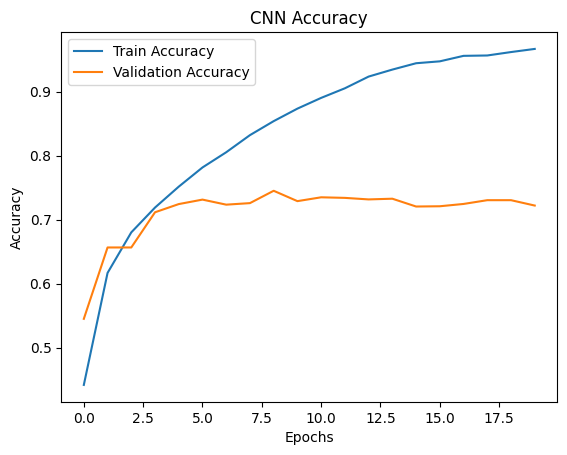

In [19]:
# Plot training vs validation accuracy for Neural Network
plt.plot(nn_model.history.history['accuracy'], label='Train Accuracy')
plt.plot(nn_model.history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Neural Network Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training vs validation accuracy for CNN
plt.plot(cnn_model.history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_model.history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


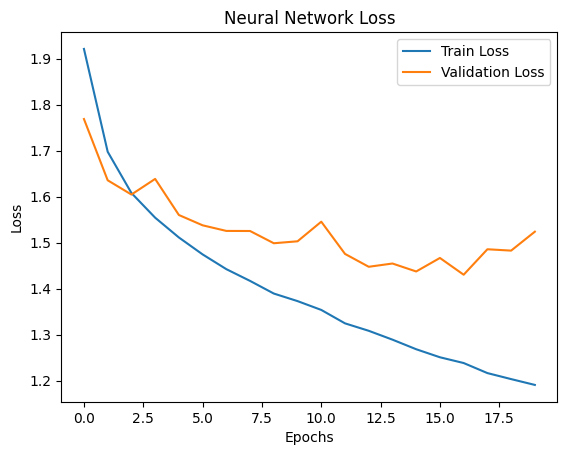

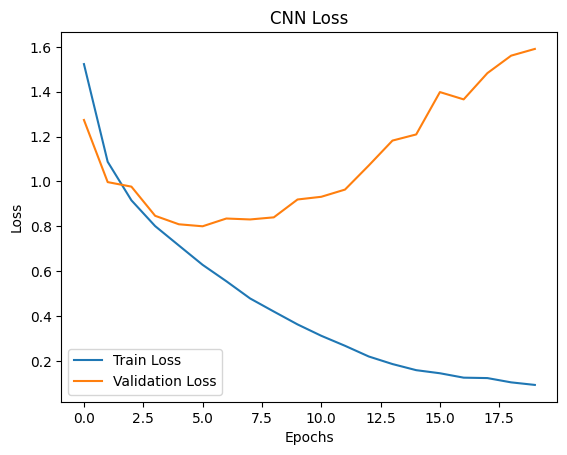

In [20]:
# Plot training vs validation loss for Neural Network
plt.plot(nn_model.history.history['loss'], label='Train Loss')
plt.plot(nn_model.history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training vs validation loss for CNN
plt.plot(cnn_model.history.history['loss'], label='Train Loss')
plt.plot(cnn_model.history.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [30]:
def plot_predictions(model, test_images, test_labels):
    # Get predictions on the flattened images (NN model works with flattened images)
    predictions = model.predict(test_images)

    # Reshape flattened test images for plotting (only for visualization)
    test_images_reshaped = test_images.reshape(-1, 32, 32, 3)

    plt.figure(figsize=(10, 5))

    for i in range(5):
        plt.subplot(1, 5, i + 1)
        plt.imshow(test_images_reshaped[i])  # Plot reshaped images
        plt.title(f"True: {np.argmax(test_labels[i])}\nPred: {np.argmax(predictions[i])}")
        plt.axis('off')

    plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


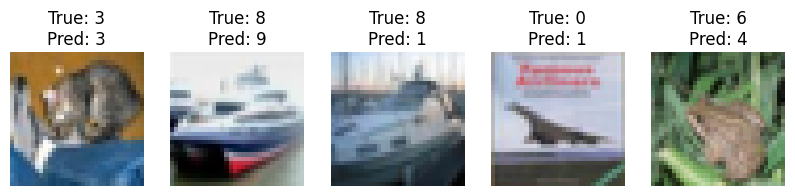

In [31]:
test_images_reshaped = x_test_flat.reshape(-1, 32, 32, 3)
plot_predictions(nn_model, x_test_flat, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step


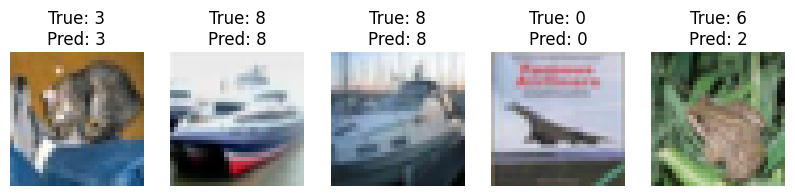

In [32]:
plot_predictions(cnn_model, x_test_cnn, y_test)


Model Comparison & Discussion

In [ ]:
print(cnn_acc)
print(nn_acc)

Which model performed better?

CNN

Why does the CNN achieve higher accuracy?

CNNs are better suited for image data because they can capture spatial features (edges, textures, etc.) that are crucial for image classification. Unlike fully connected networks, CNNs apply convolutional layers to extract hierarchical features from the images.

What happens when image data is flattened for a Neural Network?

When you flatten image data, the spatial relationships between neighboring pixels are lost. Fully connected networks treat each pixel independently, whereas CNNs take advantage of the spatial hierarchy of the image through convolutions, leading to better performance in tasks like image classification.